### Task 1: Pipeline de Dados Baseado em Ordinal Encoding

In [1]:
"""
Notebook 07: Entity Embeddings e ResNet Tabular
Fase 2 e 3 do ADR-006: Substituição de OHE por Espaços Latentes e Skip Connections.
"""
import os
import sys

sys.path.append(os.path.abspath(os.path.join('..')))

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from torch.utils.data import DataLoader, Dataset

from src.ml_telco_churn.config import CONFIG
# Copie a classe FocalLoss inteira aqui, caso não dê para importar facilmente do notebook 06
class FocalLoss(nn.Module):
    def __init__(self, alpha: float = 0.75, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p_t = torch.exp(-bce_loss)
        focal_weight = self.alpha * (1 - p_t) ** self.gamma
        return (focal_weight * bce_loss).mean()

# Constantes locais
RANDOM_STATE = CONFIG.random_state
TEST_SIZE = 0.2
VAL_SIZE = 0.15
BATCH_SIZE = 256
N_EPOCHS = 300
PATIENCE = 20
N_TRIALS_OPTUNA = 20
EXPERIMENT_NAME = "05_PyTorch_ResNet_Embeddings"

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

# 1. Carregar Dados Brutos
df_cust = pd.read_csv('../notebooks/data/raw/churn_customers.csv')
df_serv = pd.read_csv('../notebooks/data/raw/churn_services.csv')
df_cont = pd.read_csv('../notebooks/data/raw/churn_contracts.csv')

df = df_cust.merge(df_serv, on='customerID').merge(df_cont, on='customerID')
df = df.rename(columns={'customerID': 'CustomerID', 'tenure': 'Tenure', 'gender': 'Gender'})
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

/Users/eduardobatista/Code/ML_TELCO_CHURN/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Feature Engineering (idêntico ao ntbk 04/05)
df['is_monthly_contract'] = (df['Contract'] == 'Month-to-month').astype(int)
df['is_new_customer'] = (df['Tenure'] <= 6).astype(int)

df['charges_per_tenure'] = np.where(df['Tenure'] > 0, df['TotalCharges'] / df['Tenure'], df['MonthlyCharges'])
high_spender_threshold = df['MonthlyCharges'].quantile(0.75)
df['is_high_spender'] = (df['MonthlyCharges'] >= high_spender_threshold).astype(int)

service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
def count_services(row):
    return sum(1 for col in service_cols if row[col] not in ['No', 'No internet service', 'No phone service'])

df['total_services_count'] = df.apply(count_services, axis=1)
protection_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
def has_protection(row):
    return int(any(row[col] == 'Yes' for col in protection_cols))
df['has_protection_services'] = df.apply(has_protection, axis=1)

df = df.drop(columns=['CustomerID'])

In [3]:
target_col = 'Churn'
X = df.drop(columns=[target_col])
y = df[target_col]

# Separar numéricas e categóricas logicamente
num_cols = X.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Divisão de dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=y_train)

# Construir pré-processador para Ordinal Encoding (TROCANDO O OHE)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Fit e transformar dados
X_tr_proc = preprocessor.fit_transform(X_tr)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

# Importante: Como o unknown_value é -1, mapeamos +1 em todas as categóricas (0 fica vazio/unknown)
num_features_idx = len(num_cols)
X_tr_proc[:, num_features_idx:] += 1
X_val_proc[:, num_features_idx:] += 1
X_test_proc[:, num_features_idx:] += 1

# Contar cardinalidades das features categóricas (+2 para unknown(0) e máximo offset)
cat_cardinalities = [len(preprocessor.transformers_[1][1].named_steps['ordinal'].categories_[i]) + 2 for i in range(len(cat_cols))]

### Task 2: Dataset PyTorch Customizado

In [4]:
class ChurnEmbeddingDataset(Dataset):
    """Dataset que separa variáveis categóricas (para Embeddings) e numéricas."""
    def __init__(self, X_proc: np.ndarray, y: np.ndarray, num_features_cnt: int):
        self.X_num = torch.tensor(X_proc[:, :num_features_cnt], dtype=torch.float32)
        # Cast para long é obrigatório para camadas nn.Embedding
        self.X_cat = torch.tensor(X_proc[:, num_features_cnt:], dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_num[idx], self.X_cat[idx], self.y[idx]

# Instanciando Datasets
dataset_tr = ChurnEmbeddingDataset(X_tr_proc, y_tr.values, num_features_idx)
dataset_val = ChurnEmbeddingDataset(X_val_proc, y_val.values, num_features_idx)
dataset_test = ChurnEmbeddingDataset(X_test_proc, y_test.values, num_features_idx)

loader_tr = DataLoader(dataset_tr, batch_size=BATCH_SIZE, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False)

### Task 3: Classes ResNetBlock e AdvancedChurnMLP

In [5]:
class ResNetBlock(nn.Module):
    """Bloco Residual constante para dados tabulares usando LayerNorm e GELU."""
    def __init__(self, dim: int, dropout_rate: float):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.lin1 = nn.Linear(dim, dim)
        self.act = nn.GELU()
        self.drop1 = nn.Dropout(dropout_rate)
        self.lin2 = nn.Linear(dim, dim)
        self.drop2 = nn.Dropout(dropout_rate)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.norm(x)
        out = self.lin1(out)
        out = self.act(out)
        out = self.drop1(out)
        out = self.lin2(out)
        out = self.drop2(out)
        return x + out

In [6]:
class AdvancedChurnMLP(nn.Module):
    """
    Rede Neural Tabular Avançada usando Entity Embeddings para categóricas e blocos ResNet.
    """
    def __init__(self, num_dim: int, cat_cardinalities: list, hidden_dim: int, num_blocks: int, dropout_rate: float):
        super().__init__()
        
        # Heurística FastAI para dimensionamento: min(50, (cardinality // 2) + 1)
        self.embeddings = nn.ModuleList([
            nn.Embedding(card, min(50, (card // 2) + 1)) for card in cat_cardinalities
        ])
        
        total_emb_dim = sum(min(50, (card // 2) + 1) for card in cat_cardinalities)
        self.total_input_dim = num_dim + total_emb_dim
        
        self.initial_projection = nn.Sequential(
            nn.Linear(self.total_input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )
        
        self.blocks = nn.Sequential(*[
            ResNetBlock(hidden_dim, dropout_rate) for _ in range(num_blocks)
        ])
        
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x_num: torch.Tensor, x_cat: torch.Tensor) -> torch.Tensor:
        emb_outputs = []
        for i, emb_layer in enumerate(self.embeddings):
            emb_outputs.append(emb_layer(x_cat[:, i]))
            
        if emb_outputs:
            x_cat_emb = torch.cat(emb_outputs, dim=1)
            x = torch.cat([x_num, x_cat_emb], dim=1)
        else:
            x = x_num
            
        x = self.initial_projection(x)
        x = self.blocks(x)
        return self.head(x)

### Task 4: Treinamento Avançado e Integração Optuna

In [7]:
def train_advanced(model, loader_tr, dataset_val, focal_gamma, focal_alpha, max_lr, weight_decay):
    criterion = FocalLoss(alpha=focal_alpha, gamma=focal_gamma).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=weight_decay)
    
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=max_lr, steps_per_epoch=len(loader_tr), epochs=N_EPOCHS, pct_start=0.3
    )
    
    best_pr_auc = 0.0
    patience_cnt = 0
    best_state = None
    history = []
    
    X_num_val = dataset_val.X_num.to(device)
    X_cat_val = dataset_val.X_cat.to(device)
    y_val_t = dataset_val.y.to(device)
    
    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        train_losses = []
        for X_num, X_cat, yb in loader_tr:
            X_num, X_cat, yb = X_num.to(device), X_cat.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_num, X_cat), yb)
            loss.backward()
            optimizer.step()
            scheduler.step()
            train_losses.append(loss.item())
            
        model.eval()
        with torch.no_grad():
            val_logits = model(X_num_val, X_cat_val)
            val_loss = criterion(val_logits, y_val_t).item()
            val_probs = torch.sigmoid(val_logits).cpu().numpy()
            val_pr_auc = average_precision_score(y_val_t.cpu().numpy(), val_probs)
            
        history.append({"epoch": epoch, "val_loss": val_loss, "val_pr_auc": val_pr_auc})
        
        if val_pr_auc > best_pr_auc:
            best_pr_auc = val_pr_auc
            patience_cnt = 0
            best_state = model.state_dict()
        else:
            patience_cnt += 1
            
        if patience_cnt >= PATIENCE:
            break
            
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

In [8]:
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment(EXPERIMENT_NAME)

def objective(trial):
    hidden_dim = trial.suggest_categorical("hidden_dim", [64, 128, 256])
    num_blocks = trial.suggest_int("num_blocks", 2, 4)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.4)
    focal_gamma = trial.suggest_float("focal_gamma", 0.0, 5.0)
    focal_alpha = trial.suggest_float("focal_alpha", 0.1, 0.9)
    max_lr = trial.suggest_float("max_lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)
    
    model = AdvancedChurnMLP(num_features_idx, cat_cardinalities, hidden_dim, num_blocks, dropout_rate).to(device)
    
    model, history = train_advanced(model, loader_tr, dataset_val, focal_gamma, focal_alpha, max_lr, weight_decay)
    
    return max(h['val_pr_auc'] for h in history)

study = optuna.create_study(direction="maximize", study_name="resnet_emb_tuning")
study.optimize(objective, n_trials=N_TRIALS_OPTUNA)

# Treinar modelo final
best = study.best_params
final_model = AdvancedChurnMLP(num_features_idx, cat_cardinalities, best["hidden_dim"], best["num_blocks"], best["dropout_rate"]).to(device)
final_model, history = train_advanced(final_model, loader_tr, dataset_val, best["focal_gamma"], best["focal_alpha"], best["max_lr"], best["weight_decay"])

# Avaliação no Test Set
final_model.eval()
with torch.no_grad():
    X_num_test = dataset_test.X_num.to(device)
    X_cat_test = dataset_test.X_cat.to(device)
    test_probs = torch.sigmoid(final_model(X_num_test, X_cat_test)).cpu().numpy()
    test_pr_auc = average_precision_score(dataset_test.y.numpy(), test_probs)

# Log no MLflow com correção de Assinatura e Warnings
with mlflow.start_run(run_name="MLP_ResNet_Embeddings"):
    mlflow.log_params(best)
    mlflow.log_metric("test_pr_auc", test_pr_auc)
    
    final_model.cpu()
    
    sample_num = dataset_test.X_num[:1].numpy().astype(np.float32)
    sample_cat = dataset_test.X_cat[:1].numpy().astype(np.int64)
    out_sig = final_model(torch.tensor(sample_num), torch.tensor(sample_cat)).detach().numpy()
    
    from mlflow.models.signature import infer_signature
    sig = infer_signature({"x_num": sample_num, "x_cat": sample_cat}, out_sig)
    
    mlflow.pytorch.log_model(
        final_model, 
        name="model",
        registered_model_name="MLP_ResNet_Embeddings",
        signature=sig
    )
    
    print(f"TEST PR-AUC FINAL: {test_pr_auc:.4f}")

[I 2026-04-24 12:39:57,586] A new study created in memory with name: resnet_emb_tuning


[I 2026-04-24 12:40:05,550] Trial 0 finished with value: 0.6619437682691561 and parameters: {'hidden_dim': 256, 'num_blocks': 4, 'dropout_rate': 0.11537565395295198, 'focal_gamma': 4.423900821105102, 'focal_alpha': 0.508219986846509, 'max_lr': 0.00013965700308321425, 'weight_decay': 0.0009314943246595038}. Best is trial 0 with value: 0.6619437682691561.


[I 2026-04-24 12:40:10,626] Trial 1 finished with value: 0.6669570173616967 and parameters: {'hidden_dim': 128, 'num_blocks': 4, 'dropout_rate': 0.34662734807097023, 'focal_gamma': 1.5873471128057743, 'focal_alpha': 0.312061232435453, 'max_lr': 0.0013569624968134393, 'weight_decay': 1.2806793097883712e-05}. Best is trial 1 with value: 0.6669570173616967.


[I 2026-04-24 12:40:13,353] Trial 2 finished with value: 0.6752055509954267 and parameters: {'hidden_dim': 256, 'num_blocks': 2, 'dropout_rate': 0.3056607836421284, 'focal_gamma': 0.7452944012567819, 'focal_alpha': 0.19358780663288544, 'max_lr': 0.006308578044904104, 'weight_decay': 0.0005029671707193468}. Best is trial 2 with value: 0.6752055509954267.


[I 2026-04-24 12:40:19,599] Trial 3 finished with value: 0.6784666073113637 and parameters: {'hidden_dim': 128, 'num_blocks': 2, 'dropout_rate': 0.2318876548955531, 'focal_gamma': 2.30480723336892, 'focal_alpha': 0.3290552626678376, 'max_lr': 0.0003850790178517252, 'weight_decay': 1.3651969747584218e-05}. Best is trial 3 with value: 0.6784666073113637.


...

[I 2026-04-24 12:42:24,123] Trial 18 finished with value: 0.6845364042554448 and parameters: {'hidden_dim': 64, 'num_blocks': 3, 'dropout_rate': 0.15254515927867643, 'focal_gamma': 3.43251407520786, 'focal_alpha': 0.6307560835088561, 'max_lr': 0.00017469643113003728, 'weight_decay': 9.825606095524854e-05}. Best is trial 6 with value: 0.6956106636846209.


[I 2026-04-24 12:42:30,410] Trial 19 finished with value: 0.671585006456249 and parameters: {'hidden_dim': 64, 'num_blocks': 4, 'dropout_rate': 0.21684902579236334, 'focal_gamma': 1.981431175170549, 'focal_alpha': 0.3510271468050845, 'max_lr': 0.001649293572716731, 'weight_decay': 1.980479944139778e-05}. Best is trial 6 with value: 0.6956106636846209.


2026/04/24 12:42:38 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


TEST PR-AUC FINAL: 0.6400


Registered model 'MLP_ResNet_Embeddings' already exists. Creating a new version of this model...
Created version '4' of model 'MLP_ResNet_Embeddings'.


LogReg Baseline Test PR-AUC: 0.6553


/Users/eduardobatista/Code/ML_TELCO_CHURN/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


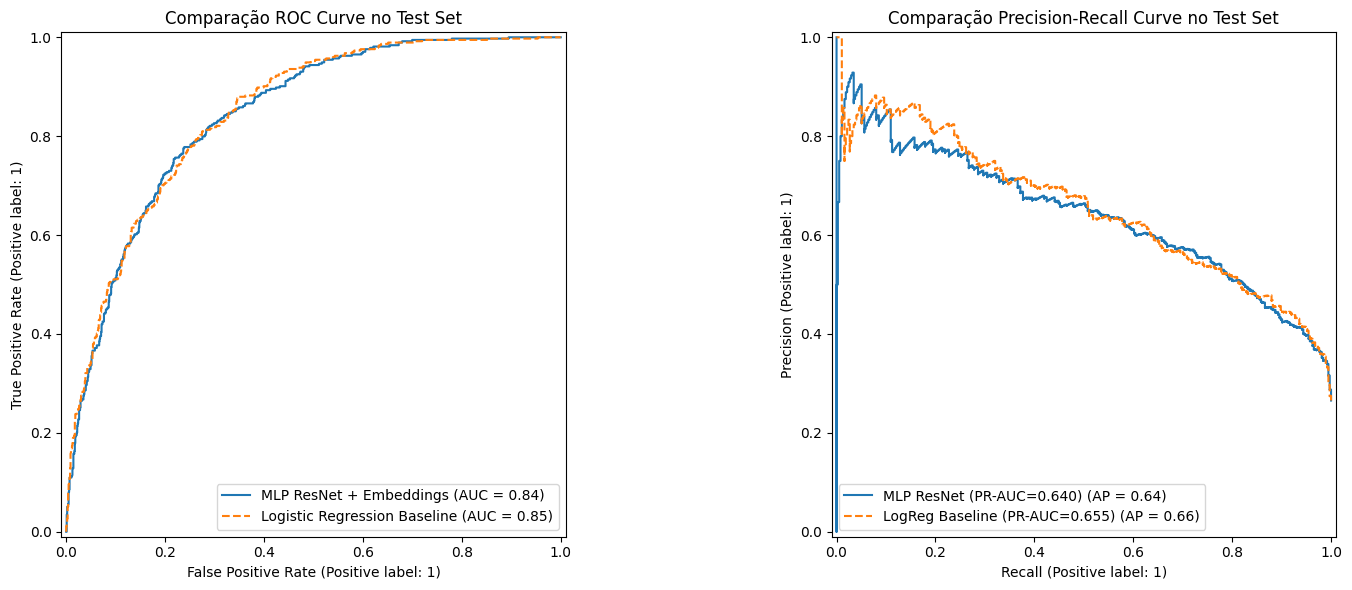

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
from sklearn.preprocessing import OneHotEncoder

lr_cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

lr_preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', lr_cat_pipeline, cat_cols)
])

X_tr_lr = lr_preprocessor.fit_transform(X_tr)
X_test_lr = lr_preprocessor.transform(X_test)

lr_model = LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000)
lr_model.fit(X_tr_lr, y_tr)
lr_probs = lr_model.predict_proba(X_test_lr)[:, 1]

lr_pr_auc = average_precision_score(y_test, lr_probs)
print(f"LogReg Baseline Test PR-AUC: {lr_pr_auc:.4f}")

# Plotagem das Curvas
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

RocCurveDisplay.from_predictions(y_test, test_probs, name="MLP ResNet + Embeddings", ax=ax[0])
RocCurveDisplay.from_predictions(y_test, lr_probs, name="Logistic Regression Baseline", ax=ax[0], linestyle="--")
ax[0].set_title("Comparação ROC Curve no Test Set")

PrecisionRecallDisplay.from_predictions(y_test, test_probs, name=f"MLP ResNet (PR-AUC={test_pr_auc:.3f})", ax=ax[1])
PrecisionRecallDisplay.from_predictions(y_test, lr_probs, name=f"LogReg Baseline (PR-AUC={lr_pr_auc:.3f})", ax=ax[1], linestyle="--")
ax[1].set_title("Comparação Precision-Recall Curve no Test Set")

plt.tight_layout()
plt.show()

with mlflow.start_run(run_name="MLP_ResNet_Embeddings", nested=True) as run:
    fig.savefig("comparison_curves.png")
    mlflow.log_artifact("comparison_curves.png")